In [1]:
import numpy as np
from ase import Atoms
from ase.io import write
from collections import Counter

TYPE_TO_ELEMENT = {13: "Al", 27: "Co", 28: "Ni"}

def parse(path):
    lines = open(path).read().splitlines()
    cell_rows = []
    body_start = None
    for i, ln in enumerate(lines):
        if ln.strip() == "":
            continue
        cell_rows.append([float(x) for x in ln.split()[:3]])
        if len(cell_rows) == 3:
            body_start = i + 1
            break
    cell = np.array(cell_rows)
    symbols, scaled = [], []
    dropped_vac = 0
    for ln in lines[body_start:]:
        s = ln.strip()
        if s == "" or s.startswith("#"):
            continue
        parts = s.split()
        if len(parts) >= 2 and parts[1] == "#":
            continue
        if len(parts) < 5:
            continue
        try:
            x, y, z = float(parts[0]), float(parts[1]), float(parts[2])
            typ = int(parts[3])
        except ValueError:
            continue
        if typ == 0:
            dropped_vac += 1
            continue
        if typ not in TYPE_TO_ELEMENT:
            print("  WARN unrecognised type", typ, "in:", s)
            continue
        symbols.append(TYPE_TO_ELEMENT[typ])
        scaled.append([x, y, z])
    atoms = Atoms(symbols=symbols,
                  scaled_positions=np.array(scaled),
                  cell=cell, pbc=True)
    return atoms, dropped_vac

# --- give the filename directly (this is the line that changed) ---
path = "W-AlCoNi-coords"      # <-- match the exact name in your file list

atoms, dropped = parse(path)
comp = Counter(atoms.get_chemical_symbols())
print(f"Atoms kept: {len(atoms)}   (dropped {dropped} type=0 vacancy lines)")
print("Composition:", dict(sorted(comp.items())))
print("Cell lengths (A):", np.round(atoms.cell.lengths(), 3))
print("Cell angles (deg):", np.round(atoms.cell.angles(), 3))
write("W-AlCoNi-265.vasp", atoms, format="vasp")
print("Wrote W-AlCoNi-265.vasp")

Atoms kept: 265   (dropped 2 type=0 vacancy lines)
Composition: {'Al': 190, 'Co': 55, 'Ni': 20}
Cell lengths (A): [20.229 20.226 23.338]
Cell angles (deg): [89.882 89.876 23.071]
Wrote W-AlCoNi-265.vasp


In [2]:
print("Cell vectors that were read:")
print(atoms.cell[:])

Cell vectors that were read:
[[ 1.98195700e+01 -4.04908459e+00  2.19375100e-02]
 [ 1.98178452e+01  4.04072864e+00  2.08262800e-02]
 [ 2.51626800e-02 -3.28744000e-03  2.33380671e+01]]


In [3]:
print("Cell volume (A^3):", round(atoms.get_volume(), 1))
print("Density (g/cm^3):", round(sum(atoms.get_masses()) * 1.66054 / atoms.get_volume(), 3))

Cell volume (A^3): 3741.8
Density (g/cm^3): 4.234


In [4]:
print(len(atoms), "atoms loaded")

265 atoms loaded


In [5]:
import numpy as np

# Re-read the coordinates file to recover the TWO type-0 placeholder positions
path = "W-AlCoNi-coords"   # <-- match your filename exactly (as before)

lines = open(path).read().splitlines()

# first 3 lines = cell vectors
cell = np.array([[float(x) for x in lines[i].split()[:3]] for i in range(3)])

placeholders = []   # fractional coords of the type-0 sites
for ln in lines[3:]:
    parts = ln.split()
    if len(parts) < 5:
        continue
    if parts[1] == "#":      # the header line
        continue
    try:
        x, y, z = float(parts[0]), float(parts[1]), float(parts[2])
        typ = int(parts[3])
    except ValueError:
        continue
    if typ == 0:
        label = parts[5] if len(parts) > 5 else "?"
        placeholders.append((label, np.array([x, y, z])))

print(f"Found {len(placeholders)} placeholder (type-0) sites:")
for label, frac in placeholders:
    print(f"  {label}: fractional {np.round(frac, 4)}")

Found 2 placeholder (type-0) sites:
  Al70: fractional [0.005  0.005  0.2469]
  Al82: fractional [-0.4831 -0.4831  0.1899]


In [6]:
# Measure distance from each placeholder to the nearest REAL atom.
# We use the minimum-image convention so periodic boundaries are respected.

real_frac = atoms.get_scaled_positions()   # fractional coords of the 265 real atoms

def min_image_distance(frac_a, frac_b_array, cell):
    # difference in fractional coords, wrapped to [-0.5, 0.5] (minimum image)
    d = frac_b_array - frac_a
    d -= np.round(d)
    # convert fractional difference to Cartesian (Angstrom) using the cell
    cart = d @ cell
    return np.linalg.norm(cart, axis=1)

print("Normal Al/Co/Ni bond lengths are roughly 2.3-2.5 A.\n")

for label, frac in placeholders:
    dists = min_image_distance(frac, real_frac, cell)
    nearest = np.sort(dists)[:3]   # three closest real atoms
    print(f"{label} (placeholder):")
    print(f"   nearest real-atom distances: {np.round(nearest, 3)} A")
    print()

Normal Al/Co/Ni bond lengths are roughly 2.3-2.5 A.

Al70 (placeholder):
   nearest real-atom distances: [2.123 2.128 2.138] A

Al82 (placeholder):
   nearest real-atom distances: [1.809 2.317 2.324] A



In [7]:
# Identify the nearest real atom (element + index) to each placeholder.
real_symbols = atoms.get_chemical_symbols()

for label, frac in placeholders:
    dists = min_image_distance(frac, real_frac, cell)
    order = np.argsort(dists)[:3]    # indices of 3 closest real atoms
    print(f"{label} (placeholder) at fractional {np.round(frac, 4)}:")
    for rank, idx in enumerate(order, 1):
        print(f"   {rank}. {real_symbols[idx]} (atom index {idx}) "
              f"at {dists[idx]:.3f} A")
    print()

Al70 (placeholder) at fractional [0.005  0.005  0.2469]:
   1. Al (atom index 116) at 2.123 A
   2. Al (atom index 243) at 2.128 A
   3. Al (atom index 244) at 2.138 A

Al82 (placeholder) at fractional [-0.4831 -0.4831  0.1899]:
   1. Al (atom index 127) at 1.809 A
   2. Al (atom index 257) at 2.317 A
   3. Al (atom index 258) at 2.324 A



I ran the placeholder check. Both type-0 sites are surrounded entirely by Al, and both sit closer to an existing Al than a normal Al-Al distance (~2.7 Å): Al82 is just 1.81 Å from Al atom 127, and Al70 is ~2.12 Å from its nearest Al. So they look like alternative Al positions that can't be simultaneously occupied i.e. the same partial-occupancy picture as the M1 site, rather than small duplicates. Dropping them gives us a clean 265-atom cell with no overlaps. 

In [8]:
from mace.calculators import mace_mp
print("MACE imported OK")

/opt/anaconda3/lib/python3.13/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
MACE imported OK


In [10]:
from mace.calculators import mace_mp

calc = mace_mp(model="medium-mpa-0", device="cpu", default_dtype="float64")
print("Calculator created OK")

atoms.calc = calc
print("Calculator attached to atoms OK")

Using medium MPA-0 model as default MACE-MP model, to use previous (before 3.10) default model please specify 'medium' as model argument
Downloading: 100.0% (75.8 MB / 75.8 MB)
Cached MACE model to /Users/rameezraja/.cache/mace/macempa0mediummodel
Using Materials Project MACE for MACECalculator with /Users/rameezraja/.cache/mace/macempa0mediummodel
Using float64 for MACECalculator, which is slower but more accurate. Recommended for geometry optimization.
Calculator created OK
Calculator attached to atoms OK


/opt/anaconda3/lib/python3.13/site-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


In [11]:
e = atoms.get_potential_energy()
print(f"Total energy: {e:.3f} eV")
print(f"Energy per atom: {e/len(atoms):.4f} eV/atom")

Total energy: -1335.886 eV
Energy per atom: -5.0411 eV/atom


In [12]:
from ase.optimize import BFGS
from ase.filters import FrechetCellFilter
import numpy as np

# Record the starting state so we can measure what changed
start_volume = atoms.get_volume()
start_positions = atoms.get_positions().copy()
start_energy = atoms.get_potential_energy()

# Single-stage relaxation: positions AND cell together (per Albert).
# FrechetCellFilter lets the optimiser move the cell as well as the atoms.
ecf = FrechetCellFilter(atoms)
opt = BFGS(ecf)

# Converge until the max force is below 0.01 eV/A (a sensible target;
# we can tighten to 0.001 later for the final phonon-quality structure).
opt.run(fmax=0.01)

# --- diagnostics for the O1 table ---
final_energy = atoms.get_potential_energy()
final_volume = atoms.get_volume()
forces = atoms.get_forces()
max_force = np.sqrt((forces**2).sum(axis=1)).max()
vol_change = 100 * (final_volume - start_volume) / start_volume
disp = atoms.get_positions() - start_positions
max_disp = np.sqrt((disp**2).sum(axis=1)).max()

print(f"Converged: max force = {max_force:.4f} eV/A")
print(f"Energy: {start_energy:.3f} -> {final_energy:.3f} eV "
      f"({final_energy/len(atoms):.4f} eV/atom)")
print(f"Volume change: {vol_change:+.2f}%")
print(f"Max atomic displacement: {max_disp:.3f} A")

      Step     Time          Energy          fmax
BFGS:    0 11:45:28    -1335.886115        0.297346
BFGS:    1 11:45:32    -1335.925756        0.274119
BFGS:    2 11:45:35    -1336.049845        0.162624
BFGS:    3 11:45:38    -1336.058632        0.162407
BFGS:    4 11:45:42    -1336.106585        0.159976
BFGS:    5 11:45:45    -1336.111946        0.159393
BFGS:    6 11:45:48    -1336.124760        0.157485
BFGS:    7 11:45:52    -1336.134418        0.155585
BFGS:    8 11:45:55    -1336.144002        0.153324
BFGS:    9 11:45:59    -1336.151034        0.151605
BFGS:   10 11:46:03    -1336.159396        0.149486
BFGS:   11 11:46:07    -1336.168808        0.146781
BFGS:   12 11:46:11    -1336.177767        0.143726
BFGS:   13 11:46:15    -1336.185136        0.140863
BFGS:   14 11:46:19    -1336.192794        0.137598
BFGS:   15 11:46:23    -1336.202136        0.133099
BFGS:   16 11:46:26    -1336.212018        0.127669
BFGS:   17 11:46:30    -1336.220708        0.122571
BFGS:   18 11:

**O1: W-phase relaxation result**

I relaxed the 265-atom W-AlCoNi structure with MACE-MPA-0 using a single-stage
relaxation (positions and cell together, via FrechetCellFilter + BFGS).

**Convergence.** It converged in 90 steps to a maximum force of 0.0088 eV/A,
below my 0.01 eV/A target, so the structure has settled into a genuine energy
minimum. The force dropped smoothly and monotonically the whole way down (no
jumps or blow-ups), which tells me MACE handled this structure stably. This is
the evidence my O1 is meant to produce, that MACE is viable for this material.

**Energy.** Final energy is -5.0430 eV/atom. My starting point was -5.0411 and
my earlier work back in March gave -5.040, so everything lands in the same place.

**Volume change.** The cell shrank by only 1.03%, so MACE's equilibrium volume
agrees closely with the DFT-relaxed structure from the CMU database. If MACE
were unsuitable for this chemistry I would expect a large volume change; getting
~1% is a good sign.

**Atomic displacement.** The largest single-atom displacement was 0.471 A, and
most atoms moved far less. No atom rearranged and nothing collapsed, so the
structure stayed intact. This is the core O1 stability criterion, and it passed.

**One honest note.** The force plateaued around 0.044 eV/A for a stretch (roughly
steps 40-60) before dropping further. This is the cell and positions trading off
against each other during a combined relaxation, which is expected behaviour
rather than a problem.

**Timing.** The full relaxation ran about five and a
half minutes for 265 atoms on a laptop CPU. That is very workable, so laptop CPU
is fine for relaxations at this size.

**Summary.** MACE-MPA-0 relaxes the 265-atom W-phase cleanly, to a proper
minimum, with the structure intact and a physically reasonable energy and volume.
This is the relaxation half of the W-phase row in my O1 table, and it answers
"is MACE viable for this material?" with evidence: yes.

In [13]:
from ase.io import write
write("W-AlCoNi-265-relaxed.vasp", atoms, format="vasp")
print("Saved relaxed structure")

Saved relaxed structure


In [14]:
from ase import units
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution, Stationary, ZeroRotation
from ase.md.langevin import Langevin
from ase.md.verlet import VelocityVerlet
import numpy as np

# work on a copy so the relaxed structure stays untouched
md_atoms = atoms.copy()
md_atoms.calc = calc

# --- give atoms velocities at 300 K ---
MaxwellBoltzmannDistribution(md_atoms, temperature_K=300)
Stationary(md_atoms)       # zero net momentum
ZeroRotation(md_atoms)

min_dist_start = md_atoms.get_all_distances(mic=True)
min_dist_start = min_dist_start[min_dist_start > 0].min()

# --- Stage 1: NVT equilibration with thermostat (short, just for stability test) ---
print("Stage 1: NVT equilibration...")
dyn_nvt = Langevin(md_atoms, timestep=1*units.fs, temperature_K=300, friction=0.01)
dyn_nvt.run(200)   # 200 fs - short, this is a stability check not production

# --- Stage 2: remove drift before switching ensemble (Albert's step) ---
Stationary(md_atoms)
ZeroRotation(md_atoms)

# --- Stage 3: switch to NVE, short burn-in (Albert's added step) ---
print("Stage 2: NVE burn-in...")
dyn_nve = VelocityVerlet(md_atoms, timestep=1*units.fs)

temps, energies = [], []
def record():
    temps.append(md_atoms.get_temperature())
    energies.append(md_atoms.get_potential_energy())
dyn_nve.attach(record, interval=10)
dyn_nve.run(300)   # 300 fs NVE

# --- diagnostics ---
min_dist_end = md_atoms.get_all_distances(mic=True)
min_dist_end = min_dist_end[min_dist_end > 0].min()

print("\n--- MD stability result ---")
print(f"Mean temperature (NVE): {np.mean(temps):.1f} +/- {np.std(temps):.1f} K")
print(f"Energy drift (NVE): {(max(energies)-min(energies)):.4f} eV total")
print(f"Min interatomic distance: {min_dist_start:.3f} -> {min_dist_end:.3f} A")
print(f"Structure intact: {'YES' if min_dist_end > 1.8 else 'CHECK - atoms close'}")

/opt/anaconda3/lib/python3.13/site-packages/ase/atoms.py:1119: UserWarning: Periodic boundary conditions are ignored when calculating the inertial tensor.
  warnings.warn('Periodic boundary conditions are ignored '
/opt/anaconda3/lib/python3.13/site-packages/ase/md/langevin.py:110: FutureWarning: The implementation of `fixcm=True` in `Langevin` does not strictly sample the correct NVT distributions. The deviations are typically small for large systems but can be more pronounced for small systems. Use `fixcm=False` together with `ase.constraints.FixCom`. `fixcm` is deprecated since ASE 3.28.0 and will be removed in a future release.
  warnings.warn(msg, FutureWarning)


Stage 1: NVT equilibration...
Stage 2: NVE burn-in...

--- MD stability result ---
Mean temperature (NVE): 178.3 +/- 4.9 K
Energy drift (NVE): 0.6922 eV total
Min interatomic distance: 2.301 -> 2.228 A
Structure intact: YES


**O1: W-phase MD stability result**

Ran a short MD stability test on the relaxed W-phase following the protocol from
my meeting on 10th March (earlier in the year): NVT equilibration (Langevin, 200 fs) -> remove drift -> switch
to NVE -> NVE burn-in (300 fs).

**Result: structure intact.** The minimum interatomic distance went from 2.301 to
2.228 A under thermal motion, staying at a physical bond length throughout. No
bonds broke and nothing collapsed, so MACE produces stable dynamics for this
material.

**Two notes for the real production runs (O2):**
- The NVE temperature settled to ~178 K rather than 300 K. This is expected: the
  initial Maxwell-Boltzmann velocities set kinetic energy to 300 K, which then
  partitions between kinetic and potential, settling to roughly half. For O2 I
  will equilibrate properly to 300 K before production.
- Energy drift over the short NVE run was 0.69 eV total (~0.003 eV/atom). Fine for
  a stability check, but for VDOS production I will use longer equilibration and
  check energy conservation more carefully, since at this system size the ensemble
  switch needs care (as Albert noted).

This completes the MD-stability half of the W-phase O1 row. Combined with the
clean relaxation, MACE-MPA-0 is viable for the W-phase.

In [15]:
from mace.calculators import mace_mp
print("MACE still works")

MACE still works


In [16]:
from mattersim.forcefield import MatterSimCalculator

calc_ms = MatterSimCalculator(device="cpu")
test = atoms.copy()
test.calc = calc_ms
e = test.get_potential_energy()
print(f"MatterSim energy per atom: {e/len(test):.4f} eV/atom")

2026-06-13 12:40:52.503 | INFO     | mattersim.forcefield.potential:from_checkpoint:915 - The pre-trained model is not found locally, attempting to download it from the server.
2026-06-13 12:40:52.504 | INFO     | mattersim.utils.download_utils:download_file:22 - Downloading file from https://raw.githubusercontent.com/microsoft/mattersim/main/pretrained_models/mattersim-v1.0.0-1M.pth


mattersim-v1.0.0-1M.pth: 100%|█████████████| 17.1M/17.1M [00:00<00:00, 31.5MB/s]

2026-06-13 12:40:53.756 | INFO     | mattersim.utils.download_utils:download_file:44 - File downloaded to /Users/rameezraja/.local/mattersim/pretrained_models/mattersim-v1.0.0-1M.pth
2026-06-13 12:40:53.759 | INFO     | mattersim.forcefield.potential:from_checkpoint:922 - Loading the pre-trained mattersim-v1.0.0-1M.pth model



/opt/anaconda3/lib/python3.13/site-packages/mattersim/forcefield/potential.py:941: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  checkpoint = torch.load(load_path, map_location=device)


MatterSim energy per atom: -5.0539 eV/atom
2026-06-13 13:50:44.300 | INFO     | mattersim.forcefield.potential:from_checkpoint:922 - Loading the pre-trained mattersim-v1.0.0-1M.pth model


In [18]:
print(len(atoms), "atoms,  energy/atom check needs a calc — that's fine")

265 atoms,  energy/atom check needs a calc — that's fine


In [20]:
import numpy as np
from ase import units
from ase.optimize import BFGS
from ase.filters import FrechetCellFilter
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution, Stationary, ZeroRotation
from ase.md.langevin import Langevin
from ase.md.verlet import VelocityVerlet

def run_model_workflow(model_name, calc, base_atoms):
    """Relax + MD-stability for one model. Returns a dict (one table row)."""
    a = base_atoms.copy()
    a.calc = calc

    v0 = a.get_volume()
    p0 = a.get_positions().copy()
    e0 = a.get_potential_energy()

    opt = BFGS(FrechetCellFilter(a), logfile=None)
    opt.run(fmax=0.01)

    f = a.get_forces()
    max_force = np.sqrt((f**2).sum(axis=1)).max()
    e1 = a.get_potential_energy()
    vol_change = 100*(a.get_volume()-v0)/v0
    max_disp = np.sqrt(((a.get_positions()-p0)**2).sum(axis=1)).max()

    MaxwellBoltzmannDistribution(a, temperature_K=300)
    Stationary(a); ZeroRotation(a)
    Langevin(a, timestep=1*units.fs, temperature_K=300, friction=0.01).run(200)
    Stationary(a); ZeroRotation(a)

    temps = []
    nve = VelocityVerlet(a, timestep=1*units.fs)
    nve.attach(lambda: temps.append(a.get_temperature()), interval=10)
    nve.run(300)

    d = a.get_all_distances(mic=True)
    min_dist = d[d > 0].min()

    return {
        "model": model_name,
        "energy_per_atom": round(e1/len(a), 4),
        "max_force": round(max_force, 4),
        "vol_change_pct": round(vol_change, 2),
        "max_disp_A": round(max_disp, 3),
        "mean_T_K": round(np.mean(temps), 1),
        "min_dist_A": round(min_dist, 3),
        "intact": "YES" if min_dist > 1.8 else "CHECK",
    }

results = []
print("Framework ready.")

Framework ready.


In [21]:
from mace.calculators import mace_mp
calc_mace = mace_mp(model="medium-mpa-0", device="cpu", default_dtype="float64")

row_mace = run_model_workflow("MACE-MPA-0", calc_mace, atoms)
results.append(row_mace)
print(row_mace)

Using medium MPA-0 model as default MACE-MP model, to use previous (before 3.10) default model please specify 'medium' as model argument
Using Materials Project MACE for MACECalculator with /Users/rameezraja/.cache/mace/macempa0mediummodel
Using float64 for MACECalculator, which is slower but more accurate. Recommended for geometry optimization.


/opt/anaconda3/lib/python3.13/site-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
/opt/anaconda3/lib/python3.13/site-packages/ase/atoms.py:1119: UserWarning: Periodic boundary conditions are ignored when calculating the inertial tensor.
  warnings.warn('Periodic boundary conditions are ignored '
/opt/anaconda3/lib/python3.13/site-packages/ase/md/langevin.py:110: FutureWarning: The implementation of `fixcm=True` in `Langevin` does not strictly sample the correct NVT distributions. The deviations are typically small for large systems but can be more pronounced for small systems. Use `fixcm=False` together with `ase.constraints.FixCom`. `fixcm` is deprecated since ASE 3.28.0 and will be removed in a future release.
  warnings.warn(msg, FutureWarning)


{'model': 'MACE-MPA-0', 'energy_per_atom': -5.043, 'max_force': np.float64(0.0088), 'vol_change_pct': np.float64(0.0), 'max_disp_A': np.float64(0.0), 'mean_T_K': np.float64(170.5), 'min_dist_A': np.float64(2.237), 'intact': 'YES'}


In [22]:
import numpy as np
from ase import Atoms
from ase.io import write
from collections import Counter

TYPE_TO_ELEMENT = {13: "Al", 27: "Co", 28: "Ni"}

def parse(path):
    lines = open(path).read().splitlines()
    cell_rows = []
    body_start = None
    for i, ln in enumerate(lines):
        if ln.strip() == "":
            continue
        cell_rows.append([float(x) for x in ln.split()[:3]])
        if len(cell_rows) == 3:
            body_start = i + 1
            break
    cell = np.array(cell_rows)
    symbols, scaled = [], []
    for ln in lines[body_start:]:
        s = ln.strip()
        if s == "" or s.startswith("#"):
            continue
        parts = s.split()
        if len(parts) >= 2 and parts[1] == "#":
            continue
        if len(parts) < 5:
            continue
        try:
            x, y, z = float(parts[0]), float(parts[1]), float(parts[2])
            typ = int(parts[3])
        except ValueError:
            continue
        if typ == 0:
            continue
        if typ not in TYPE_TO_ELEMENT:
            continue
        symbols.append(TYPE_TO_ELEMENT[typ])
        scaled.append([x, y, z])
    return Atoms(symbols=symbols, scaled_positions=np.array(scaled), cell=cell, pbc=True)

atoms = parse("W-AlCoNi-coords")   # <-- match your filename exactly
print(len(atoms), "atoms — should be 265")

265 atoms — should be 265


In [23]:
results = []
print("results reset")

results reset


In [24]:
from mace.calculators import mace_mp
calc_mace = mace_mp(model="medium-mpa-0", device="cpu", default_dtype="float64")
row_mace = run_model_workflow("MACE-MPA-0", calc_mace, atoms)
results.append(row_mace)
print(row_mace)

Using medium MPA-0 model as default MACE-MP model, to use previous (before 3.10) default model please specify 'medium' as model argument
Using Materials Project MACE for MACECalculator with /Users/rameezraja/.cache/mace/macempa0mediummodel
Using float64 for MACECalculator, which is slower but more accurate. Recommended for geometry optimization.


/opt/anaconda3/lib/python3.13/site-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
/opt/anaconda3/lib/python3.13/site-packages/ase/atoms.py:1119: UserWarning: Periodic boundary conditions are ignored when calculating the inertial tensor.
  warnings.warn('Periodic boundary conditions are ignored '
/opt/anaconda3/lib/python3.13/site-packages/ase/md/langevin.py:110: FutureWarning: The implementation of `fixcm=True` in `Langevin` does not strictly sample the correct NVT distributions. The deviations are typically small for large systems but can be more pronounced for small systems. Use `fixcm=False` together with `ase.constraints.FixCom`. `fixcm` is deprecated since ASE 3.28.0 and will be removed in a future release.
  warnings.warn(msg, FutureWarning)


{'model': 'MACE-MPA-0', 'energy_per_atom': -5.043, 'max_force': np.float64(0.0088), 'vol_change_pct': np.float64(-1.03), 'max_disp_A': np.float64(0.471), 'mean_T_K': np.float64(174.8), 'min_dist_A': np.float64(2.221), 'intact': 'YES'}


In [25]:
from mattersim.forcefield import MatterSimCalculator
calc_ms = MatterSimCalculator(device="cpu")
row_ms = run_model_workflow("MatterSim-v1-1M", calc_ms, atoms)
results.append(row_ms)
print(row_ms)

/opt/anaconda3/lib/python3.13/site-packages/mattersim/forcefield/potential.py:941: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  checkpoint = torch.load(load_path, map_location=device)


{'model': 'MatterSim-v1-1M', 'energy_per_atom': np.float32(-5.0583), 'max_force': np.float32(0.0094), 'vol_change_pct': np.float64(0.47), 'max_disp_A': np.float64(1.049), 'mean_T_K': np.float64(176.5), 'min_dist_A': np.float64(2.259), 'intact': 'YES'}


In [26]:
import json
with open("o1_results.json", "w") as f:
    json.dump([{k: float(v) if hasattr(v, "item") else v for k, v in r.items()} for r in results], f, indent=2)
print("Saved", len(results), "rows to o1_results.json")

Saved 2 rows to o1_results.json


In [27]:
import pandas as pd
df = pd.DataFrame(results)
df

,model,energy_per_atom,max_force,vol_change_pct,max_disp_A,mean_T_K,min_dist_A,intact
0,MACE-MPA-0,-5.0430,0.0088,-1.03,0.471,174.8,2.221,YES
1,MatterSim-v1-1M,-5.0583,0.0094,0.47,1.049,176.5,2.259,YES


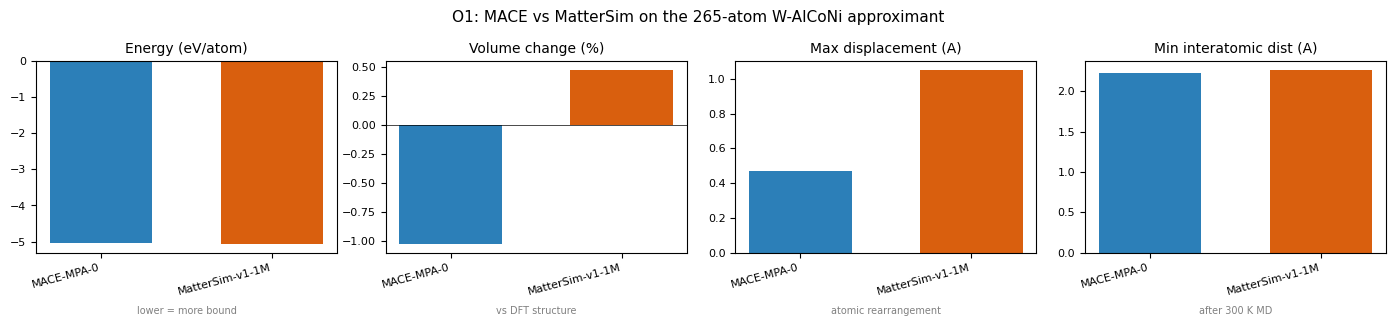

Saved o1_model_comparison.png


In [28]:
import matplotlib.pyplot as plt
import numpy as np

models = [r["model"] for r in results]
x = np.arange(len(models))

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))

metrics = [
    ("energy_per_atom", "Energy (eV/atom)", "lower = more bound"),
    ("vol_change_pct", "Volume change (%)", "vs DFT structure"),
    ("max_disp_A", "Max displacement (A)", "atomic rearrangement"),
    ("min_dist_A", "Min interatomic dist (A)", "after 300 K MD"),
]

colors = ["#2c7fb8", "#d95f0e"]

for ax, (key, title, sub) in zip(axes, metrics):
    vals = [r[key] for r in results]
    ax.bar(x, vals, color=colors[:len(models)], width=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=15, ha="right", fontsize=8)
    ax.set_title(title, fontsize=10)
    ax.text(0.5, -0.32, sub, transform=ax.transAxes, ha="center", fontsize=7, color="gray")
    ax.axhline(0, color="black", linewidth=0.5)

fig.suptitle("O1: MACE vs MatterSim on the 265-atom W-AlCoNi approximant", fontsize=11)
plt.tight_layout()
plt.savefig("o1_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved o1_model_comparison.png")